In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("survey.csv")
print(df.head())
print(df.columns)

             Timestamp  Age  Gender         Country state self_employed  \
0  2014-08-27 11:29:31   37  Female   United States    IL           NaN   
1  2014-08-27 11:29:37   44       M   United States    IN           NaN   
2  2014-08-27 11:29:44   32    Male          Canada   NaN           NaN   
3  2014-08-27 11:29:46   31    Male  United Kingdom   NaN           NaN   
4  2014-08-27 11:30:22   31    Male   United States    TX           NaN   

  family_history treatment work_interfere    no_employees  ...  \
0             No       Yes          Often            6-25  ...   
1             No        No         Rarely  More than 1000  ...   
2             No        No         Rarely            6-25  ...   
3            Yes       Yes          Often          26-100  ...   
4             No        No          Never         100-500  ...   

                leave mental_health_consequence phys_health_consequence  \
0       Somewhat easy                        No                      No   
1 

In [ ]:
df = df[['Age', 'Gender', 'work_interfere', 'treatment',
         'benefits', 'care_options', 'family_history']]

In [ ]:
df = df.dropna()

In [ ]:
df['Gender'] = df['Gender'].str.lower()

def clean_gender(x):
    if 'male' in x:
        return 'Male'
    elif 'female' in x:
        return 'Female'
    else:
        return 'Other'

df['Gender'] = df['Gender'].apply(clean_gender)

In [ ]:
df = df[(df['Age'] > 10) & (df['Age'] < 100)]

In [ ]:
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
Index: 990 entries, 0 to 1258
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Age             990 non-null    int64 
 1   Gender          990 non-null    object
 2   work_interfere  990 non-null    object
 3   treatment       990 non-null    object
 4   benefits        990 non-null    object
 5   care_options    990 non-null    object
 6   family_history  990 non-null    object
dtypes: int64(1), object(6)
memory usage: 61.9+ KB
None
   Age Gender work_interfere treatment    benefits care_options family_history
0   37   Male          Often       Yes         Yes     Not sure             No
1   44  Other         Rarely        No  Don't know           No             No
2   32   Male         Rarely        No          No           No             No
3   31   Male          Often       Yes          No          Yes            Yes
4   31   Male          Never        No         Yes   

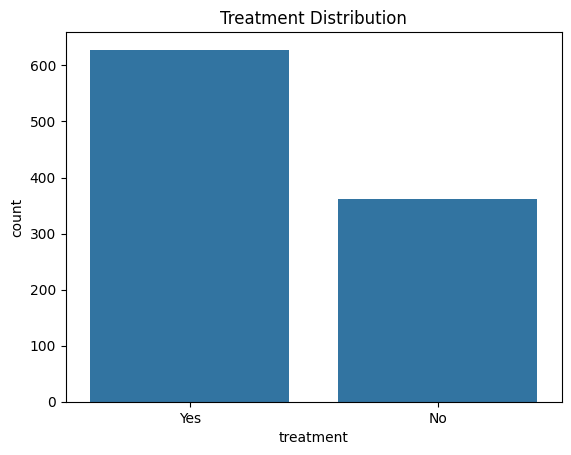

In [ ]:
#MEANINGFUL ANALYSIS
#How many people take treatment?
sns.countplot(x='treatment', data=df)
plt.title("Treatment Distribution")
plt.show()

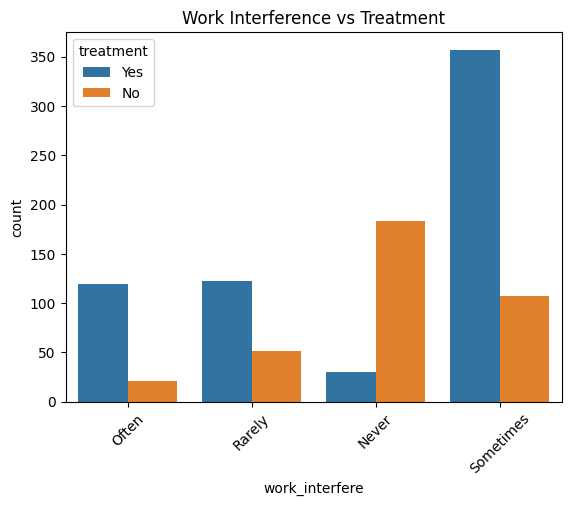

In [ ]:
#Does work affect mental health?
sns.countplot(x='work_interfere', hue='treatment', data=df)
plt.title("Work Interference vs Treatment")
plt.xticks(rotation=45)
plt.show()

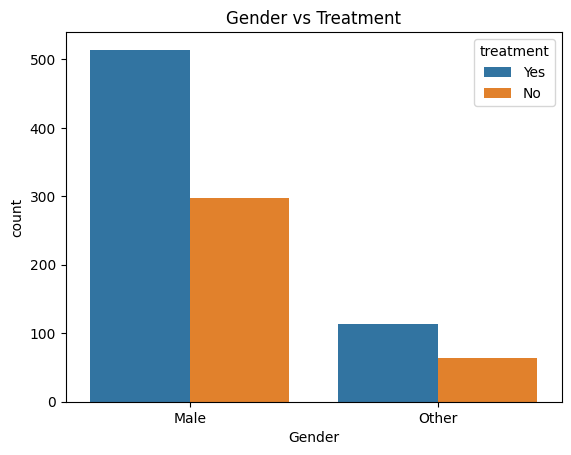

In [ ]:
#Gender vs Treatment
sns.countplot(x='Gender', hue='treatment', data=df)
plt.title("Gender vs Treatment")
plt.show()

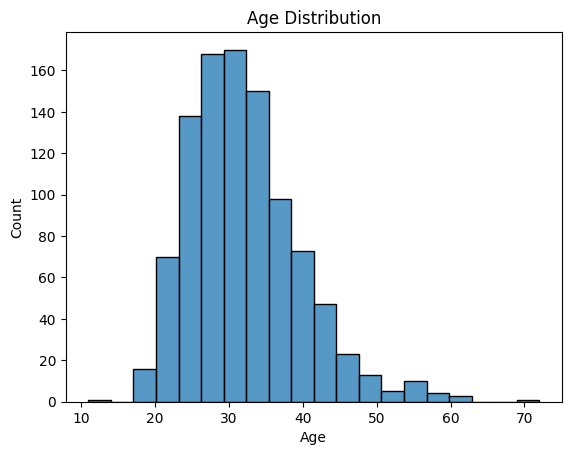

In [ ]:
#Age Distribution
sns.histplot(df['Age'], bins=20)
plt.title("Age Distribution")
plt.show()

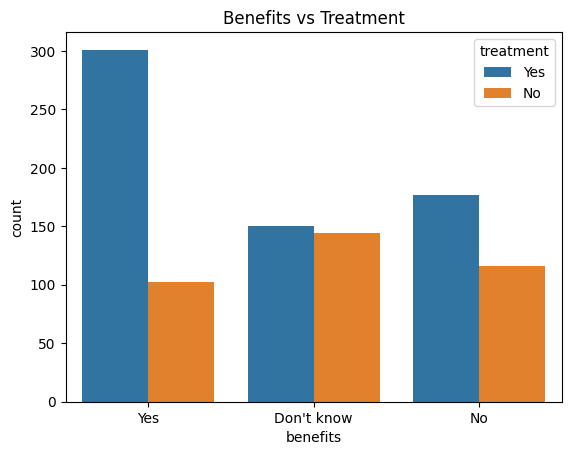

In [ ]:
#Benefits vs Treatment
sns.countplot(x='benefits', hue='treatment', data=df)
plt.title("Benefits vs Treatment")
plt.show()

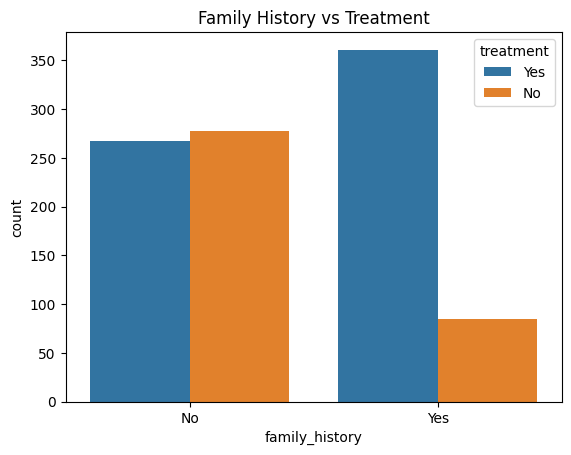

In [ ]:
#Family History Impact
sns.countplot(x='family_history', hue='treatment', data=df)
plt.title("Family History vs Treatment")
plt.show()

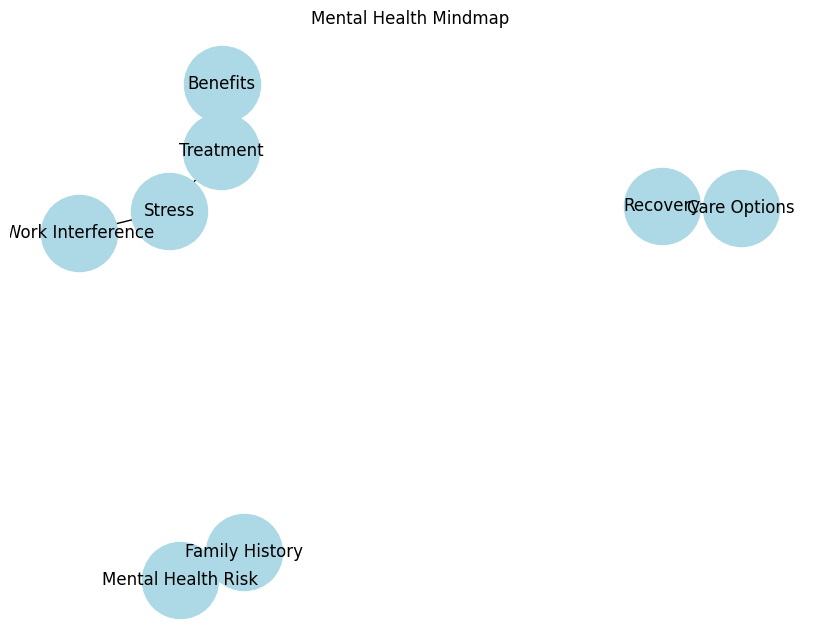

In [ ]:
#MINDMAP (RELATIONSHIPS)
import networkx as nx

G = nx.Graph()

G.add_edges_from([
    ("Work Interference", "Stress"),
    ("Stress", "Treatment"),
    ("Family History", "Mental Health Risk"),
    ("Benefits", "Treatment"),
    ("Care Options", "Recovery")
])

plt.figure(figsize=(8,6))
nx.draw(G, with_labels=True, node_color='lightblue', node_size=3000)
plt.title("Mental Health Mindmap")
plt.show()

In [ ]:
#RISK CALCULATOR
def risk_calculator(work_interfere, benefits, family_history, age):
    risk = 0

    if work_interfere in ['Often', 'Sometimes']:
        risk += 2

    if benefits == 'No':
        risk += 2

    if family_history == 'Yes':
        risk += 2

    if age < 25:
        risk += 1

    if risk >= 5:
        return "High Risk"
    elif risk >= 3:
        return "Medium Risk"
    else:
        return "Low Risk"

In [ ]:
#Testing
print(risk_calculator("Often", "No", "Yes", 22))

High Risk


In [ ]:
def risk_calculator(work_interfere, benefits, family_history, age):
    risk = 0

    work_interfere = str(work_interfere).strip()
    benefits = str(benefits).strip()
    family_history = str(family_history).strip()

    if work_interfere in ['Often', 'Sometimes']:
        risk += 2

    if benefits == 'No':
        risk += 2

    if family_history == 'Yes':
        risk += 2

    if age < 25:
        risk += 1

    if risk >= 5:
        return "High Risk"
    elif risk >= 3:
        return "Medium Risk"
    else:
        return "Low Risk"

Saving survey.csv to survey (1).csv


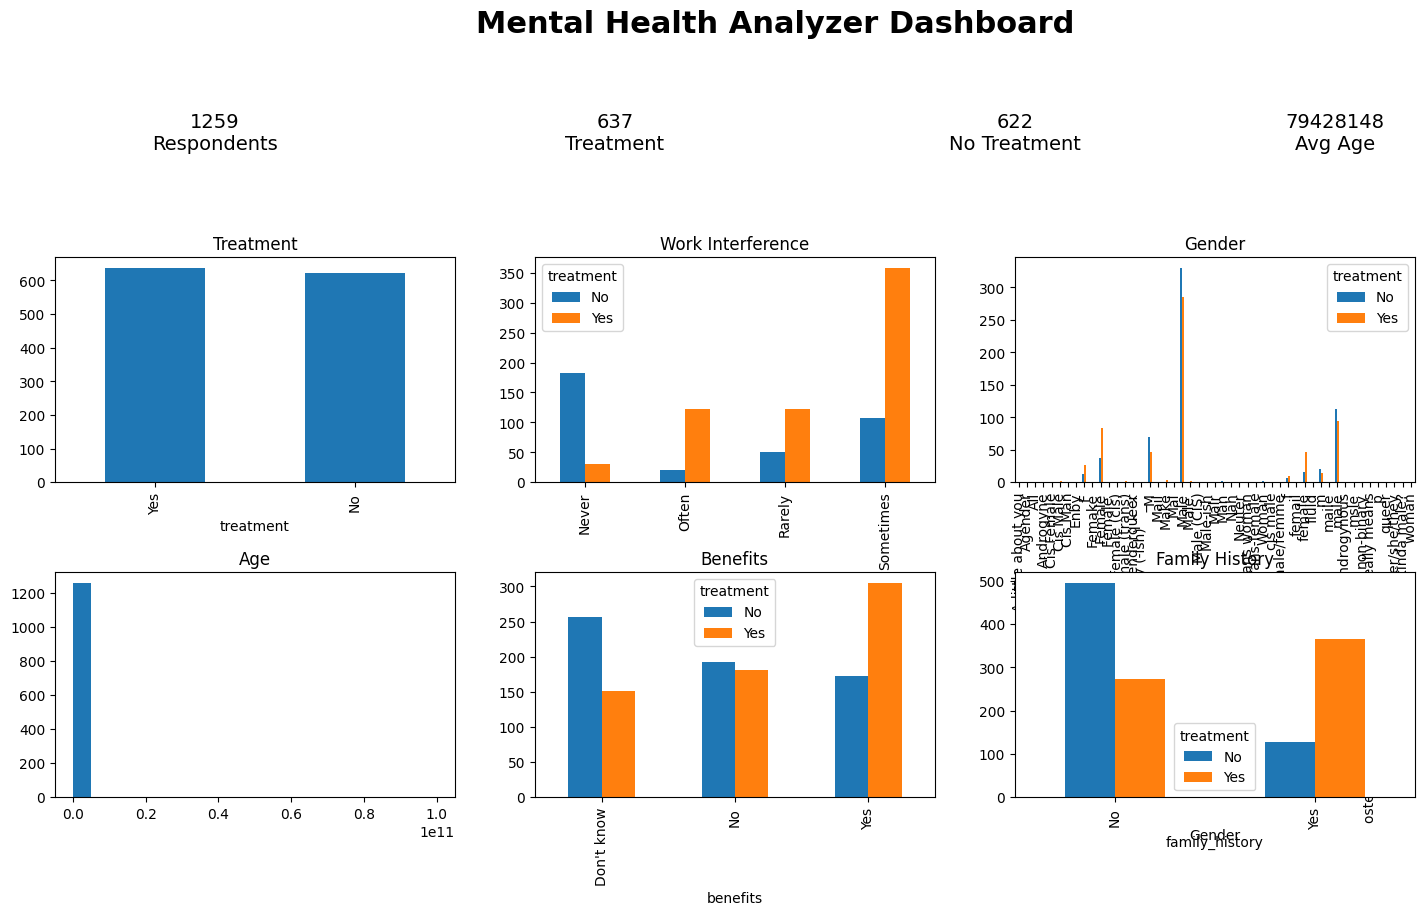

In [ ]:
# ==============================
# Mental Health Dashboard (Colab)
# ==============================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------
# OPTION 1: Upload your dataset
# ------------------------------
from google.colab import files
uploaded = files.upload()

# Replace with your file name if needed
df = pd.read_csv(list(uploaded.keys())[0])

# ------------------------------
# OPTION 2 (IF YOU DON'T UPLOAD)
# Comment above lines and use this sample
# ------------------------------
"""
np.random.seed(1)
n=1000
df=pd.DataFrame({
    "treatment": np.random.choice(["Yes","No"], n, p=[0.63,0.37]),
    "work_interfere": np.random.choice(["Often","Rarely","Never","Sometimes"], n),
    "Gender": np.random.choice(["Male","Other"], n, p=[0.8,0.2]),
    "Age": np.random.normal(30,10,n).clip(15,70),
    "benefits": np.random.choice(["Yes","No","Don't know"], n),
    "family_history": np.random.choice(["Yes","No"], n)
})
"""

# ------------------------------
# BASIC METRICS
# ------------------------------
total = len(df)
treated = (df['treatment']=="Yes").sum()
not_treated = (df['treatment']=="No").sum()
avg_age = int(df['Age'].mean())

# ------------------------------
# STYLE
# ------------------------------
plt.rcParams['font.family'] = 'DejaVu Sans'

# ------------------------------
# CREATE DASHBOARD
# ------------------------------
fig = plt.figure(figsize=(16,9))

# Title
fig.text(0.5,0.95,"Mental Health Analyzer Dashboard",ha='center',
         fontsize=22,weight='bold')

# KPI Cards (text style)
kpi_y = 0.82
fig.text(0.15,kpi_y,f"{total}\nRespondents",ha='center',fontsize=14)
fig.text(0.40,kpi_y,f"{treated}\nTreatment",ha='center',fontsize=14)
fig.text(0.65,kpi_y,f"{not_treated}\nNo Treatment",ha='center',fontsize=14)
fig.text(0.85,kpi_y,f"{avg_age}\nAvg Age",ha='center',fontsize=14)

# ------------------------------
# CHARTS
# ------------------------------

# Treatment
ax1 = plt.axes([0.05,0.45,0.25,0.25])
df['treatment'].value_counts().plot(kind='bar',ax=ax1)
ax1.set_title("Treatment")

# Work Interference
ax2 = plt.axes([0.35,0.45,0.25,0.25])
pd.crosstab(df['work_interfere'],df['treatment']).plot(kind='bar',ax=ax2)
ax2.set_title("Work Interference")

# Gender
ax3 = plt.axes([0.65,0.45,0.25,0.25])
pd.crosstab(df['Gender'],df['treatment']).plot(kind='bar',ax=ax3)
ax3.set_title("Gender")

# Age
ax4 = plt.axes([0.05,0.1,0.25,0.25])
ax4.hist(df['Age'],bins=20)
ax4.set_title("Age")

# Benefits
ax5 = plt.axes([0.35,0.1,0.25,0.25])
pd.crosstab(df['benefits'],df['treatment']).plot(kind='bar',ax=ax5)
ax5.set_title("Benefits")

# Family History
ax6 = plt.axes([0.65,0.1,0.25,0.25])
pd.crosstab(df['family_history'],df['treatment']).plot(kind='bar',ax=ax6)
ax6.set_title("Family History")

# ------------------------------
# SAVE IMAGE
# ------------------------------
plt.savefig("mental_health_dashboard.png", bbox_inches='tight')

# Show output
plt.show()

In [ ]:
# python -m pip install pandas numpy scikit-learn streamlit matplotlib

SyntaxError: invalid syntax (2873198559.py, line 1)